In [ ]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

import pymc as pm
import pytensor.tensor as pt
import pytensor
pytensor.config.cxx = '/usr/bin/clang++'

from modulars import plot_a_few_trajectories_1d, plot_mean_band_rrs_1d
from modulars import load_config, load_best_values

In [ ]:
# helpers
from modulars import binomial # data generating function
from modulars import beta_posterior

# transforms
from modulars.utils import _logistic_normal_mean_std_mc, _trace_locscale_to_theta_moments
trace_fn = _logistic_normal_mean_std_mc
pushforward_fn = _trace_locscale_to_theta_moments

from scipy.special import expit  # sigmoid


data_gen = binomial

In [ ]:
config_file = "../beta_config.json"
config = load_config(config_file)

theta_like = config['theta_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']
max_iters = 100_000

data = data_gen(n_samples) if n_samples > 0 else 0

from modulars import print_model_info
print_model_info(
    "Beta", "Binomial", "Beta",
    [alpha_prior, beta_prior], [theta_like],
    data=data, posterior_func=beta_posterior,
    n_samples=n_samples)


Prior: Beta([0.5, 0.6])
Likelihood: Binomial([0.7])
Data: 7
Posterior: Beta({'alpha_post': 7.5, 'beta_post': 3.5999999999999996, 'mean_post': 0.6756756756756757, 'std_post': np.float64(0.13457556695458628)})


In [ ]:
from modulars import run_pymc_VI, run_single_seed_pymc_VI

def run_model(n_mc_samples = 1, optimizer = 'default', seed = 1):
    with pm.Model() as model:
        # Define the prior
        theta = pm.Beta('theta', alpha=alpha_prior, beta=beta_prior)

        # Define the likelihood
        y = pm.Binomial('y', n=n_samples, p=theta, observed=data)

        # run my pymc wrapper that allows for random restarts 
        # and tracking values across MC samples and optimizers
        tracked_vals = run_pymc_VI(model, n_mc_samples, max_iters, optimizer, seed)
    return tracked_vals


In [6]:
seeds = np.arange(5)
results = []
results_adam = []
for seed in tqdm(seeds, position=0):
    all_results = run_single_seed_pymc_VI(seed, run_model)
    results.append(all_results[0])
    results_adam.append(all_results[1])

  0%|          | 0/5 [00:00<?, ?it/s]

Finished [100%]: Average Loss = 2.731
Finished [100%]: Average Loss = 2.7305
Finished [100%]: Average Loss = 2.7285
Finished [100%]: Average Loss = 2.7306
Finished [100%]: Average Loss = 2.7423
Finished [100%]: Average Loss = 2.7304
Finished [100%]: Average Loss = 2.7323
Finished [100%]: Average Loss = 2.7305
Finished [100%]: Average Loss = 2.7373
Finished [100%]: Average Loss = 2.7303
Finished [100%]: Average Loss = 2.7324
Finished [100%]: Average Loss = 2.7303
Finished [100%]: Average Loss = 2.7457
Finished [100%]: Average Loss = 2.7304
Finished [100%]: Average Loss = 2.7314
Finished [100%]: Average Loss = 2.7304
Finished [100%]: Average Loss = 2.7294
Finished [100%]: Average Loss = 2.7302
Finished [100%]: Average Loss = 2.7266
Finished [100%]: Average Loss = 2.7302


In [7]:
from modulars import apply_traj_transform
single_means, single_stds, multi_means, multi_stds = \
apply_traj_transform(results, pushforward_fn, n_samples=10_000, seed=1, NOTEBOOK=True)
N, T = single_means.shape
x = np.arange(T)

  0%|          | 0/5 [00:00<?, ?it/s]

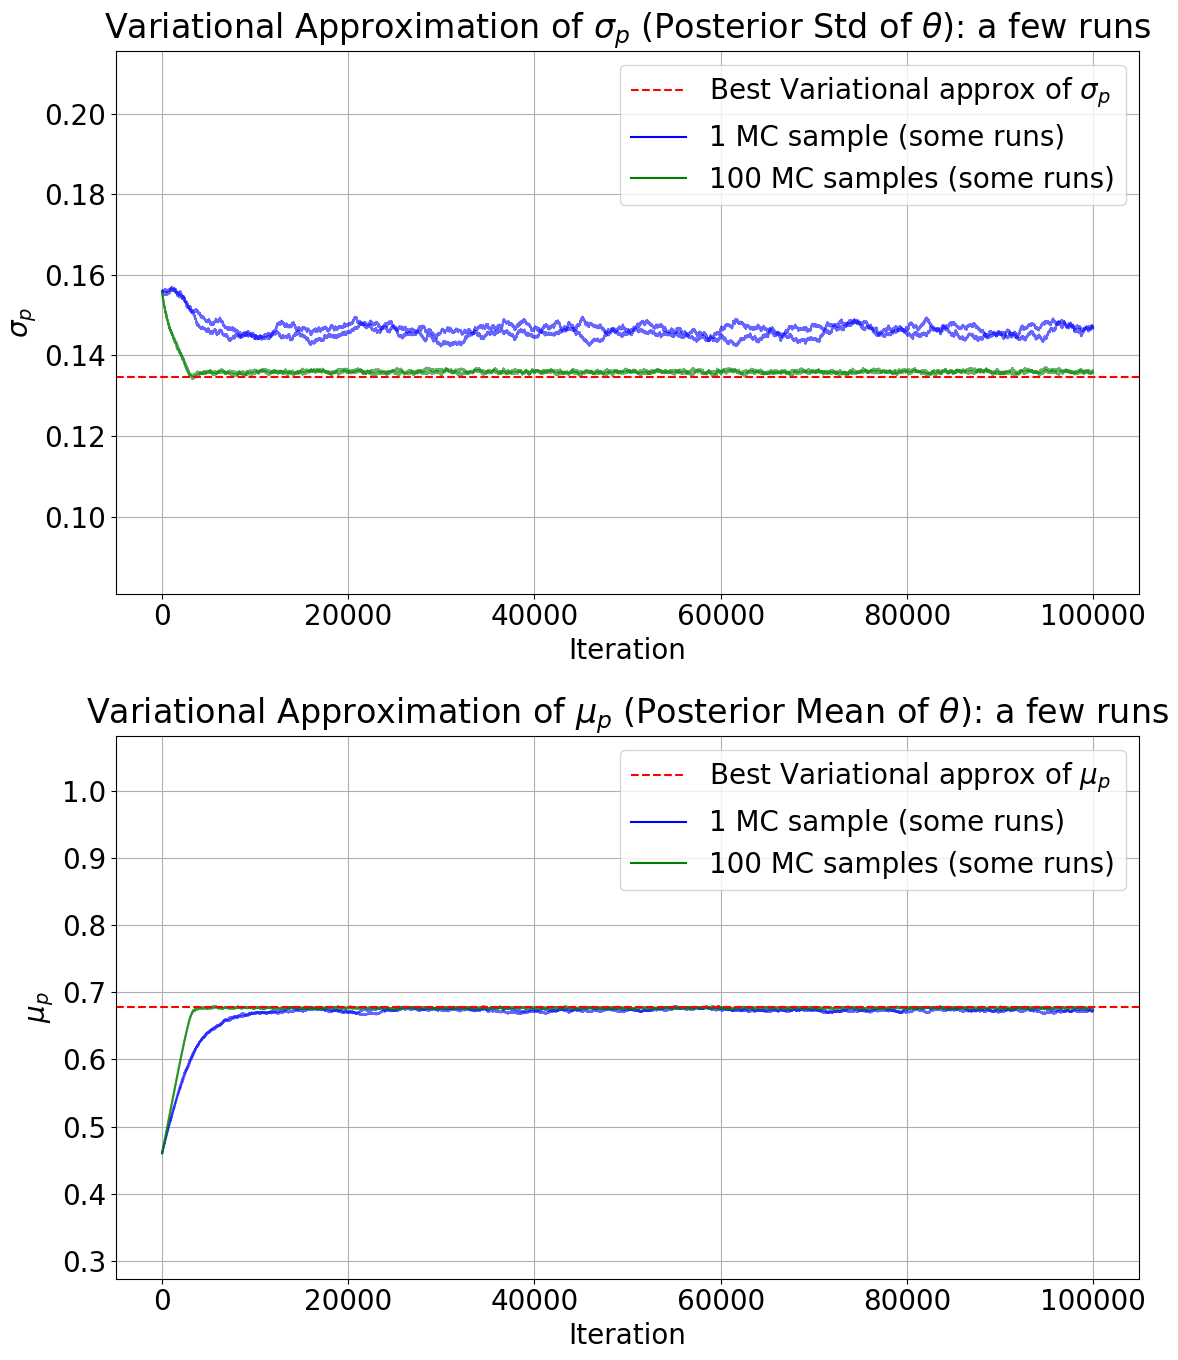

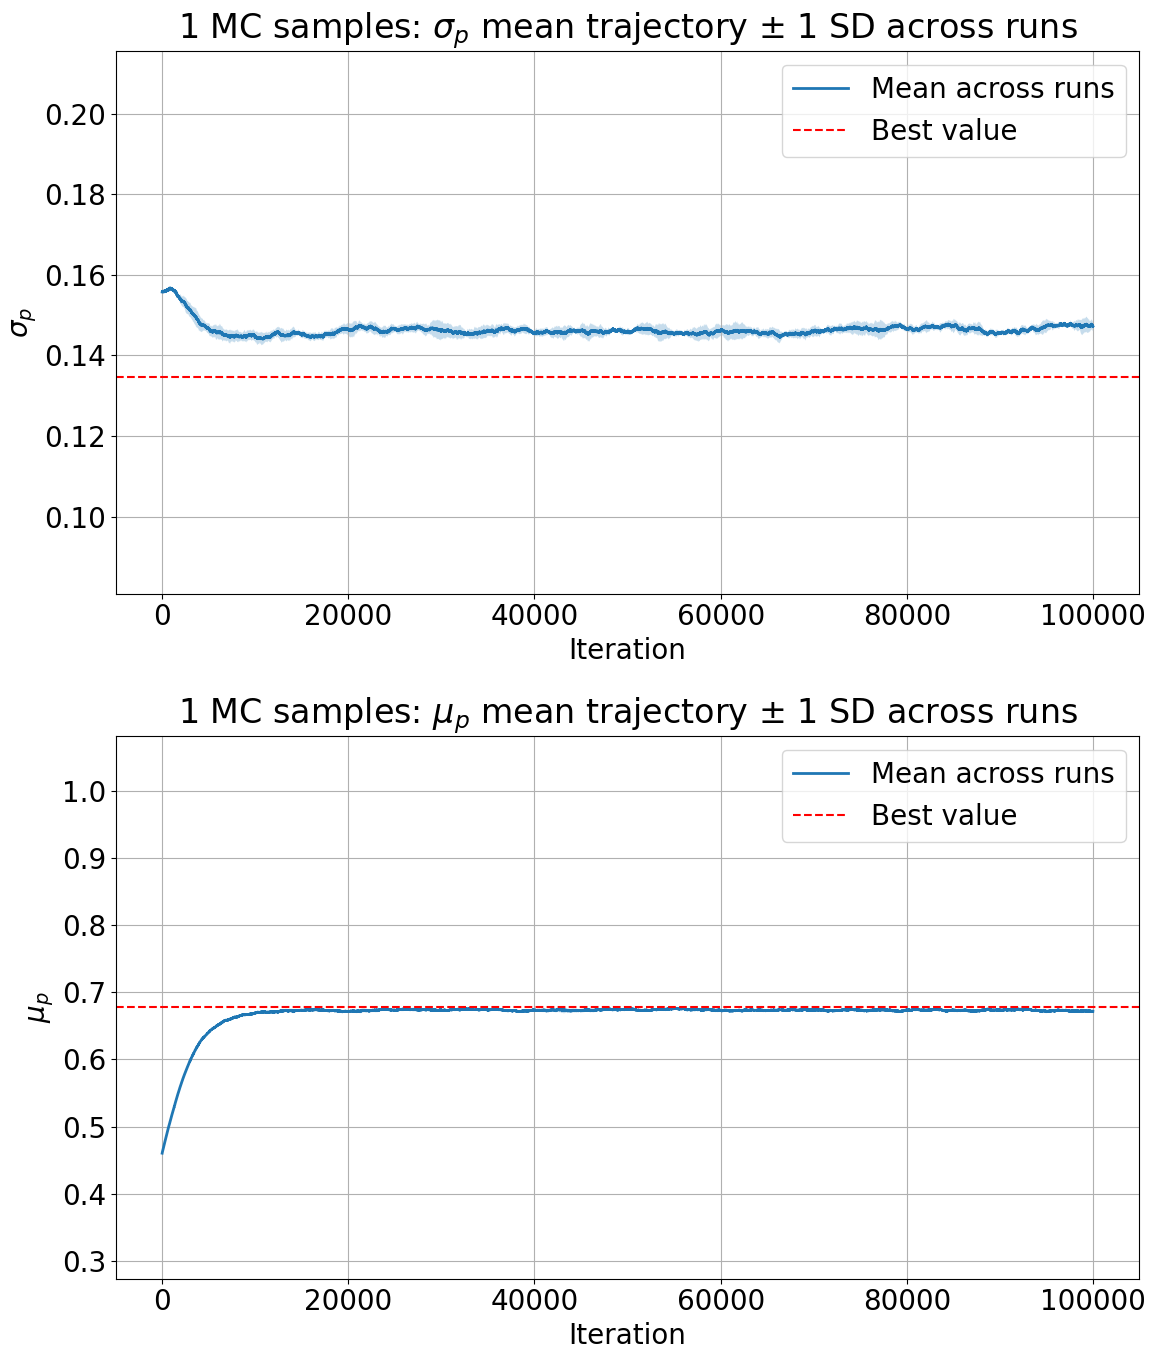

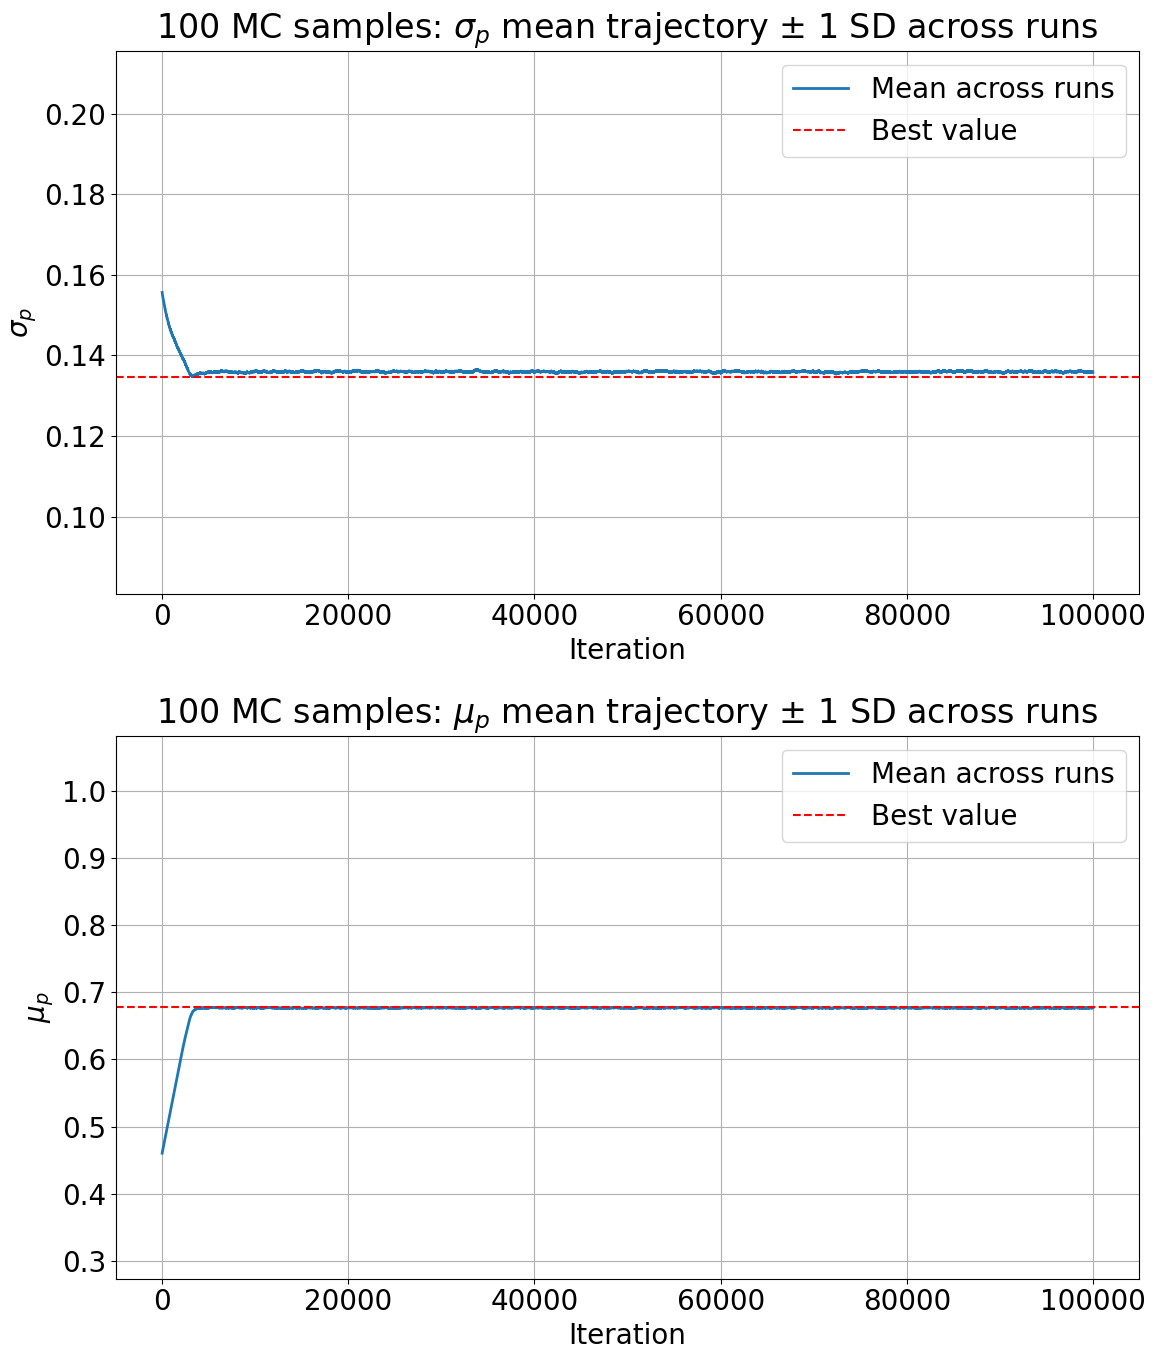

In [ ]:
# If we have "best" from config, these should be on theta-scale (0,1)
best_mu, best_std = load_best_values(
    config=config, transform=trace_fn,
    n_samples=50_000, seed=1)

plot_a_few_trajectories_1d(
    [single_means, single_stds], [multi_means, multi_stds],
    best_mu, best_std, r'$\theta$')
plot_mean_band_rrs_1d(
    single_means, single_stds, best_mu, best_std,
    x, r'$\theta$', 1)
plot_mean_band_rrs_1d(
    multi_means, multi_stds, best_mu, best_std,
    x, r'$\theta$', 100)


In [10]:
# now let's look at the adam results

# Adam results

In [11]:
single_means_adam, single_stds_adam, multi_means_adam, multi_stds_adam = \
    apply_traj_transform(results_adam, pushforward_fn, n_samples=10_000, seed=1, NOTEBOOK=True)


  0%|          | 0/5 [00:00<?, ?it/s]

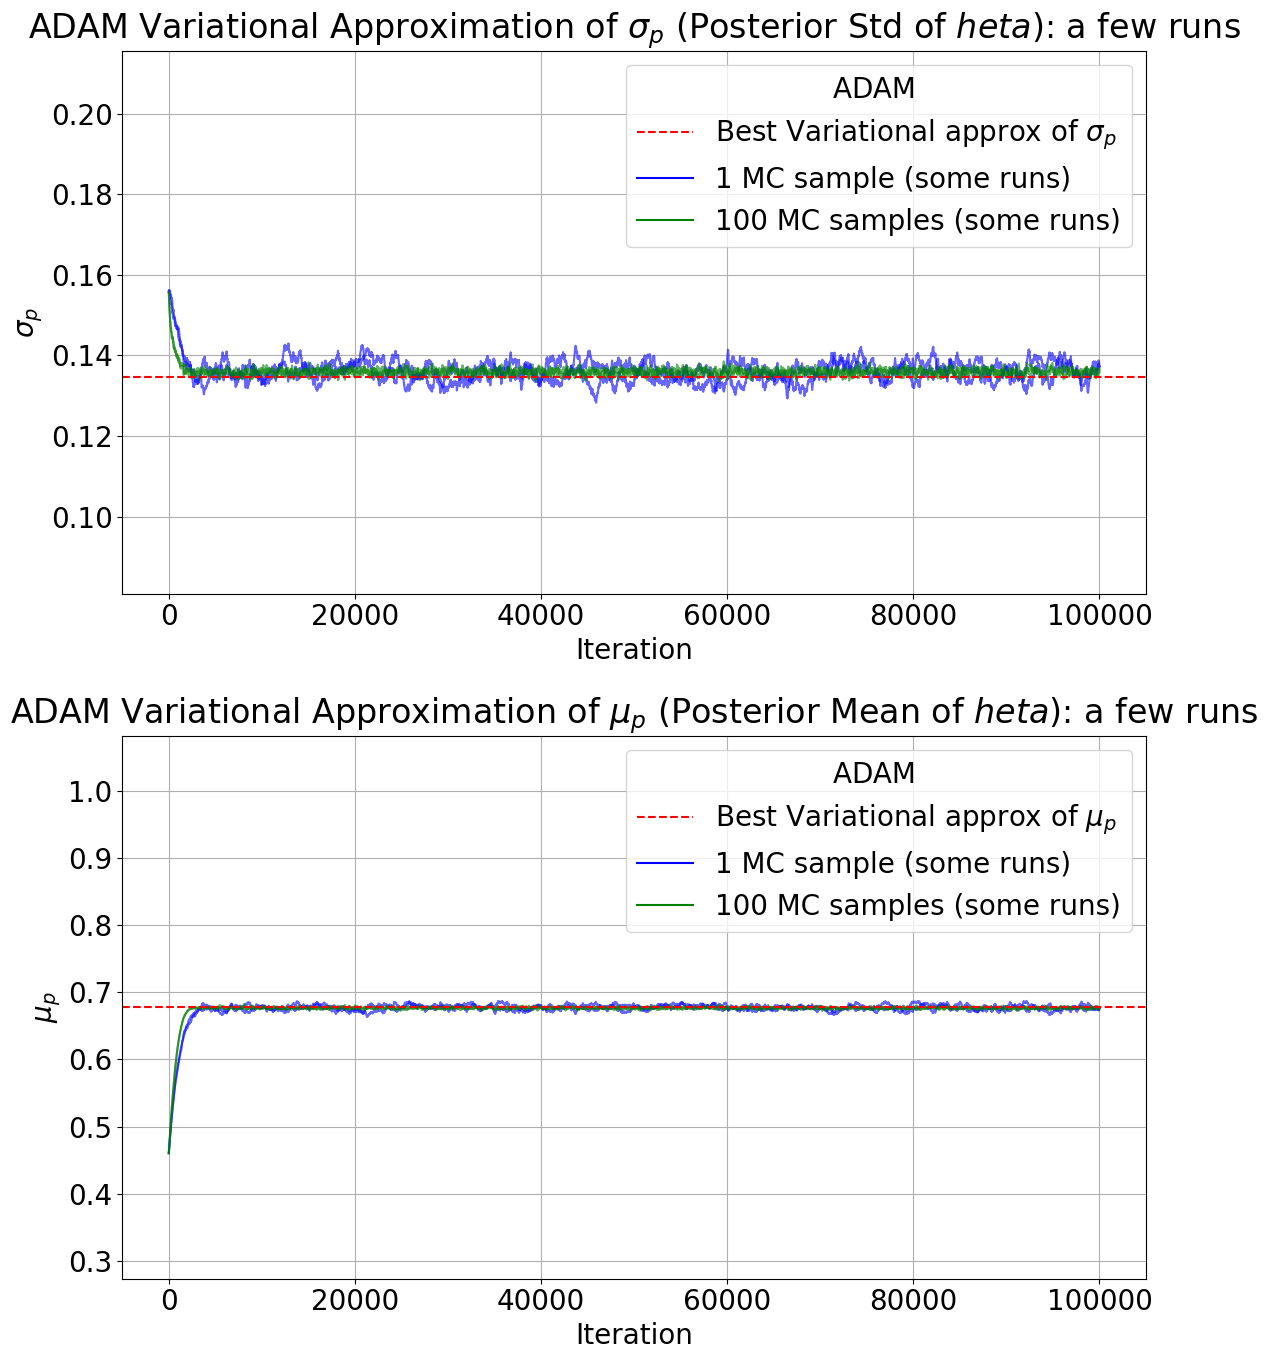

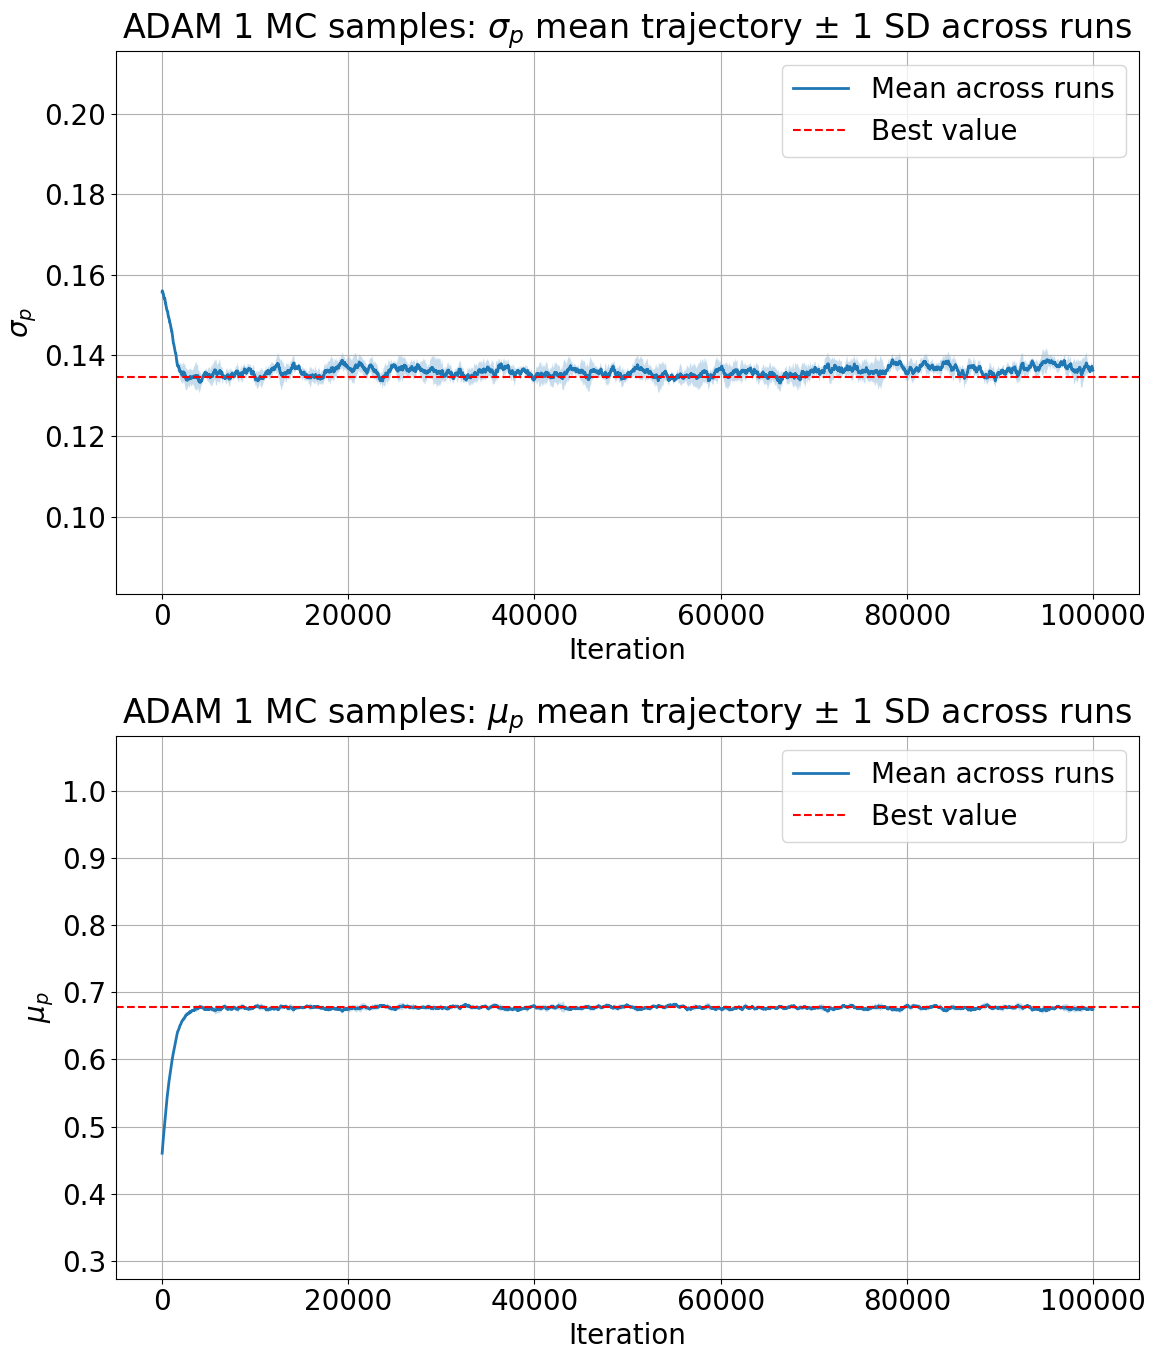

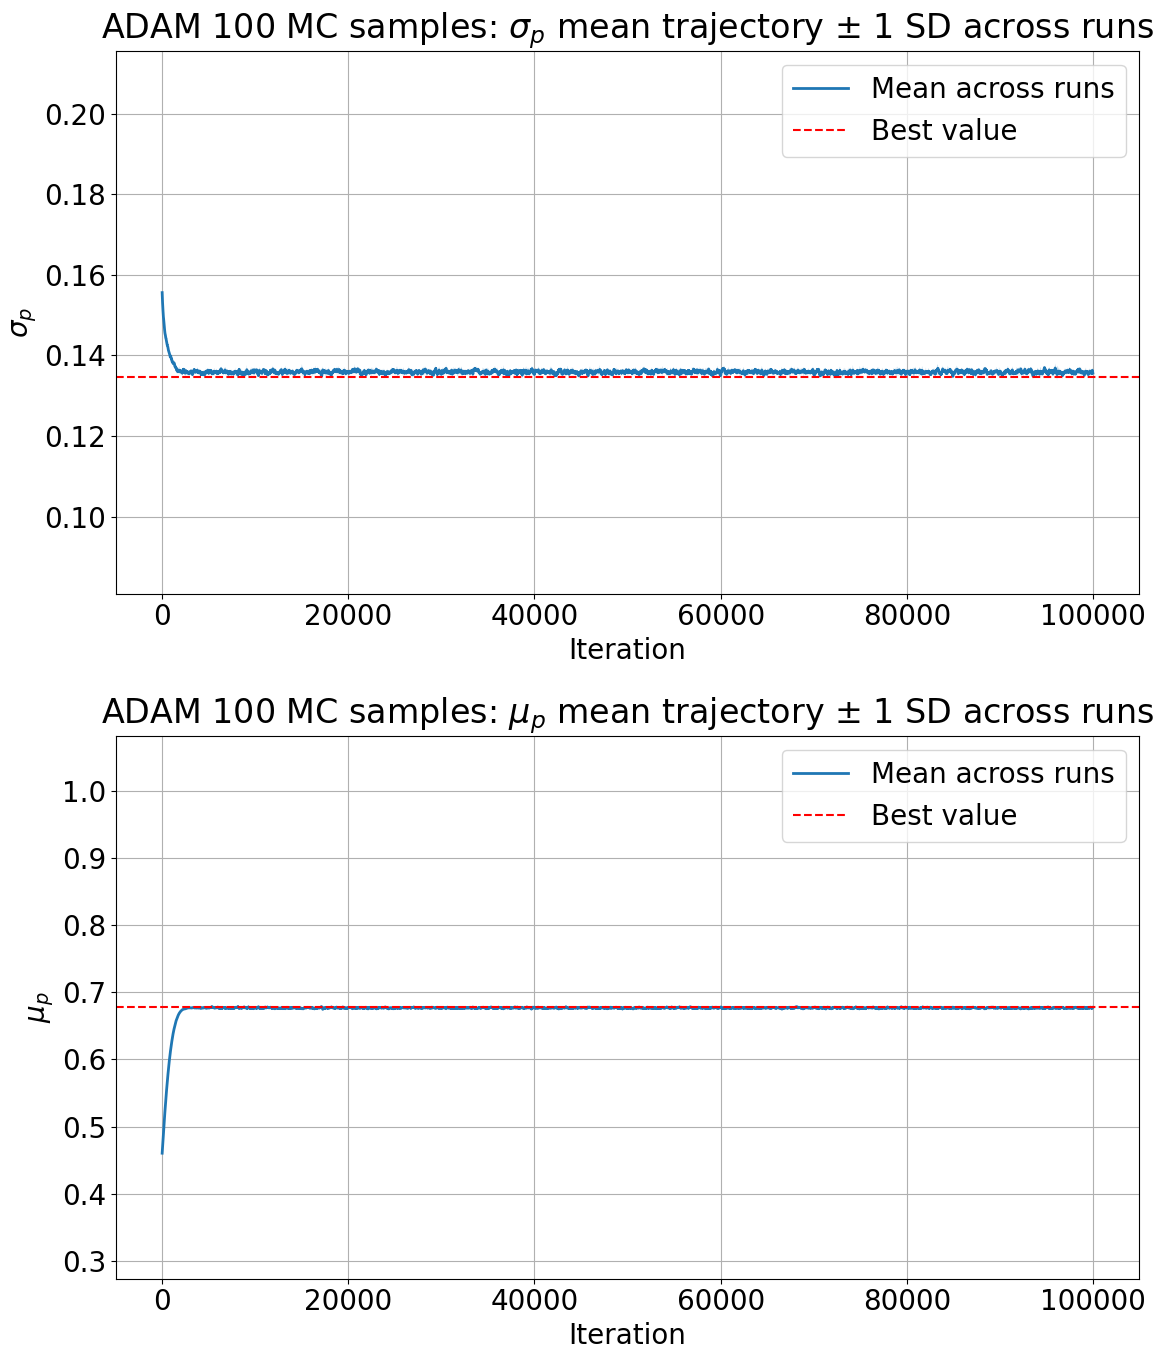

In [ ]:

plot_a_few_trajectories_1d(
    [single_means_adam, single_stds_adam], [multi_means_adam, multi_stds_adam],
    best_mu, best_std, r'$\theta$', label_prefix = 'ADAM ')
plot_mean_band_rrs_1d(
    single_means_adam, single_stds_adam, best_mu, best_std,
    x, r'$\theta$', 1, label_prefix='ADAM ')
plot_mean_band_rrs_1d(
    multi_means_adam, multi_stds_adam, best_mu, best_std,
    x, r'$\theta$', 100, label_prefix='ADAM ')